In [ ]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta,time
from scipy import stats
import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from matplotlib.ticker import MultipleLocator


In [3]:
pd.set_option("display.max_columns", None)

In [4]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent

    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [5]:
userInputDataRaw = loadDataFromFile("UserPrevious experiments-preprocessed")
timeSeriesData_BIGraw = loadDataFromFile("Data:Previous experiments-preprocessed")

C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 257 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\UserPrevious experiments-preprocessed.json
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 229277 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\Data:Previous experiments-preprocessed.json


In [6]:
timeSeriesData_BIGraw = timeSeriesData_BIGraw.set_index("seconds",drop=False)

In [7]:
a = userInputDataRaw.index
b = timeSeriesData_BIGraw["keys"].unique()
diff_all = list(set(a).symmetric_difference(set(b)))
print(diff_all)  
userInputDataRaw.index = timeSeriesData_BIGraw["keys"].unique()
print(userInputDataRaw.index)

[6, 49, 257, 258]
Index([  0,   1,   2,   3,   4,   5,   7,   8,   9,  10,
       ...
       249, 250, 251, 252, 253, 254, 255, 256, 257, 258],
      dtype='int64', length=257)


In [8]:
# Convert back to timedelta
timeSeriesData_BIGraw['timestamp'] = pd.to_timedelta(timeSeriesData_BIGraw['timestamp'], unit='ms')

# Convert back to datetime

timeSeriesData_BIGraw ["datetime_timestamp"]= timeSeriesData_BIGraw['datetime_timestamp'].transform(
    lambda x: pd.to_datetime(x, unit='ms')
)


columns_datetime= [
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment']
columns_timedelta = ['time taken total','time taken before insertion',
       'timestamp InsertingSource timedelta',
       'time taken after insertion']
# Ensure target columns are of object type before assignment
userInputDataRaw[columns_datetime] = userInputDataRaw[columns_datetime].astype('object')
userInputDataRaw[columns_timedelta] = userInputDataRaw[columns_timedelta].astype('object')

userInputDataRaw.loc[:,columns_datetime] = userInputDataRaw.loc[:,columns_datetime].apply(lambda x:pd.to_datetime(x, unit='ms'))
userInputDataRaw.loc[:,columns_timedelta] = userInputDataRaw.loc[:,columns_timedelta].apply(lambda x:pd.to_timedelta(x, unit='ms'))

In [9]:
timeSeriesData_BIG = timeSeriesData_BIGraw.copy()
userInputData = userInputDataRaw.copy()

In [10]:
#keep the data from the last set experiments made that have the 3 sensors in a triangle shape,they have 16 particular points in the space and the door is closed
room_mask = userInputData["room"].isin(['Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0', 'Κρεβατοκάμαρα Όλοι οι αισθητήρες μαζί Π:1.80 , Δ:2.00'])

open_door_mask = userInputData["are-doors-opened"] != "on"
mask = room_mask & open_door_mask
userInputData = userInputData.loc[mask]
#grab all the data that are contained in those experiments
timeSeriesData_BIG = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]

In [11]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
145,NoSourcePollutantInserted,None,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,NaN,None,on,2025-10-13 18:12:35,2025-10-13 18:12:23,2025-10-13 18:19:58,2025-10-13 00:00:00,2025-10-13 18:12:24,2025-10-13 18:19:56,0 days 00:07:32,0 days 00:00:12,12,0 days 00:07:20,0 days 00:00:12,12,440,452,288,-12,299,0.2190,299.0,0.2297,255,0.1309,299.0,Id=2:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.18758,0.210014,0.22307,0.229500,0.10019,0.129212,0.20155,0.229130,0.148821,0.000534,0.126362,0.000542,0.063558,0.000061,NaN,NaN,-1.85,3.5,-0.5,1.7,-2.25,0.4,NaN,NaN,NaN
146,InsertingSourcePollutant,None,None,None,1.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,None,2025-10-13 18:26:12,2025-10-13 18:24:06,2025-10-13 18:57:52,2025-10-13 00:00:00,2025-10-13 18:24:08,2025-10-13 18:57:50,0 days 00:33:42,0 days 00:02:05,125,0 days 00:31:37,0 days 00:02:05,125,1897,2022,270,-30,299,0.3738,251.0,0.3577,294,0.2026,224.0,Id=1:BME680:breathVocEquivalent MAX value VOC ...,Id=2:BME680:breathVocEquivalent MAX value VOC ...,0.34415,0.373413,0.33478,0.357013,0.18951,0.202442,0.32881,0.370132,0.059467,0.001485,0.068867,0.001000,0.087333,0.000453,-2.95,2.5,-1.85,3.5,-0.5,1.7,-2.25,0.4,1.49,2.58,2.21
147,InsertingSourcePollutant,None,None,None,0.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,Non

In [12]:
timeSeriesData_BIG

,keys,sensors,VOC,after_insertion,original_value,datetime_timestamp,timestamp,seconds,seconds passed from insertionSource,VOC original,VOC rolling average,original seconds,VOC-capped,VOC rolling average-capped,VOC gradient,VOC rolling average gradient,VOC rolling average standard scaler whole experiment,VOC rolling average-capped standard scaler whole experiment
seconds,,,,,,,,,,,,,,,,,,
-12,145,Id=0:BME680:breathVocEquivalent,0.119,False,False,2025-10-13 18:12:24,0 days 00:00:00,-12,-12,0.659488,0.1113,0,0.119,0.1113,-0.00160,-0.00160,-0.025275,-0.025275
-12,145,Id=1:BME680:breathVocEquivalent,0.000,False,False,2025-10-13 18:12:24,0 days 00:00:00,-12,-12,0.526446,0.0559,0,0.000,0.0559,0.00390,0.00390,-0.866511,-0.866511
-12,145,Id=2:BME680:breathVocEquivalent,0.045,False,True,2025-10-13 18:12:24,0 days 00:00:00,-12,-12,0.520286,0.0356,0,0.045,0.0356,0.00010,0.00010,-1.174762,-1.174762
-11,145,Id=0:BME680:breathVocEquivalent,0.118,False,False,2025-10-13 18:12:25,0 days 00:00:01,-11,-11,0.658610,0.1097,1,0.118,0.1097,-0.00165,-0.00165,-0.049571,-0.049571
-11,145,Id=1:BME680:breathVocEquivalent,0.006,False,False,2025-10-13 18:12:25,0 days 00:00:01,-11,-11,0.532204,0.0598,1,0.006,0.0598,0.00375,0.00375,-0.807290,-0.807290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,258,Id=1:BME680:breathVocEquivalent,1.421,True,True,2025-10-24 21:59:04,0 days 00:06:46,298,298,2.948842,1.4032,406,1.421,1.4032,-0.00500,-0.00500,0.089182,0.089182
298,258,Id=2:BME680:breathVocEquivalent,3.343,True,False,2025-10-24 21:59:04,0 days 00:06:46,298,298,5.567955,3.3352,406,3.343,3.3352,-0.00835,-0.00835,2.251684,2.251684
299,258,Id=0:BME680:breathVocEquivalent,2.143,True,False,2025-10-24 21:59:05,0 days 00:06:47,299,299,3.110278,2.1139,407,2.143,2.1139,0.01260,0.01260,0.884674,0.884674


# Split back into dict
dict_of_timeseries = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG.groupby("keys")}
for index,data in dict_of_timeseries.items():
    dict_of_timeseries[index] = dict_of_timeseries[index].set_index("seconds",drop=False)

In [13]:
def plot_position(userInputData,sample_row_of_the_group):
    plt.figure(figsize=(6, 6))  
    position_of_sensors = userInputData.iloc[-1]
    all_positions = userInputData.loc[:, ["x axis", "y axis"]]
    # Extra points
    extra_positions = np.array([
        [position_of_sensors["position of Id=0:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=0:BME680:breathVocEquivalent-y axis"]],
    
        [position_of_sensors["position of Id=1:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=1:BME680:breathVocEquivalent-y axis"]],
        [position_of_sensors["position of Id=2:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=2:BME680:breathVocEquivalent-y axis"]]
    ])
    extra_ids = ["id0","id1", "id2"]
    
    
    room_length = 4.0
    room_width = 3.25
    
    
    # Create scatterplot of the sources of all the particular setup
    #sns.scatterplot(x=positions[:,0], y=positions[:,1])
    sns.scatterplot(data=all_positions, x="x axis", y="y axis", color='blue', s=100, label='User Input Data')
    
    
    
    # Add the positions of sensors
    sns.scatterplot(x=extra_positions[:,0], y=extra_positions[:,1], color='red', s=100)
    x_sensor_highlight = sample_row_of_the_group["x axis"]
    y_sensor_highlight = sample_row_of_the_group["y axis"]
    # Plot a hollow circle around it
    plt.scatter(x_sensor_highlight, y_sensor_highlight, s=500, facecolors='none', edgecolors='green', linewidths=2, label='Highlighted point')  
    # Draw lines and annotate distances
    distances_from_sensors = (
        sample_row_of_the_group["Euclidian distance to Id=0:BME680:breathVocEquivalent"],
        sample_row_of_the_group["Euclidian distance to Id=1:BME680:breathVocEquivalent"],
        sample_row_of_the_group["Euclidian distance to Id=2:BME680:breathVocEquivalent"]
    )
    
    for i, (x, y) in enumerate(extra_positions):
        plt.plot([x_sensor_highlight, x], [y_sensor_highlight, y], color='red', linewidth=0.7, alpha=0.7)
        
        if distances_from_sensors is not None:
            # Midpoint of the line for annotation
            mid_x = (x_sensor_highlight + x) / 2
            mid_y = (y_sensor_highlight + y) / 2
            plt.text(mid_x, mid_y, f"{distances_from_sensors[i]:.2f}", color='red', fontsize=8, ha='center', va='center',
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))
    # Annotate extra points with their IDs
    for i, (x, y) in enumerate(extra_positions):
        plt.text(x, y, extra_ids[i], fontsize=12, ha='right', va='bottom', color='red')
    
    
    # Set axis limits
    plt.xlim(-room_width, 0)
    plt.ylim(0, room_length)
    
    # Add grid
    plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.7)
    # Smaller legend
    plt.legend(fontsize=8, markerscale=0.8, labelspacing=0.4)

    plt.show()

In [14]:
def printDataBasedOnDate(column_to_print,userInputData,timeSeriesData_BIG,room_other_grouping,type_of_other_grouping):
    
    column_names_keys_color_values = {"Id=0:BME680:breathVocEquivalent":"blue","Id=1:BME680:breathVocEquivalent":"green","Id=2:BME680:breathVocEquivalent":"yellow"}
    
    for group_name,indexes_of_the_group in room_other_grouping.items(): 
        timeSeriesData_BIG_copy = timeSeriesData_BIG.copy() 

        if ("position"  in type_of_other_grouping):
            sample_row_of_the_group = userInputData.loc[indexes_of_the_group[0],:]
            
            plot_position(userInputData,sample_row_of_the_group)       
        print(f"group_name {group_name}")
        print(f"indexes_of_the_group {indexes_of_the_group}")
        data = timeSeriesData_BIG_copy.loc[timeSeriesData_BIG_copy["keys"].isin(indexes_of_the_group),:]  
      # Create relplot
        g = sns.relplot(
            data=data,
            x="seconds",
            y=column_to_print,
            hue="sensors",
            col="keys",        # separate subplot per key
            kind="line",
            col_wrap=3, 
                height=7,    # default = 5
            aspect=1, # width = height × aspect (so 6 × 1.5 = 9 inches wide per subplot
            palette=column_names_keys_color_values,  # <<< ensures the same colors across all subplots  
            linewidth=2,
           facet_kws={
            "sharex": False,
            "sharey": False       
    
        })
        

        # >>> ADD THIS PART <<<
        for ax in g.axes.flat:
            ax.xaxis.set_major_locator(MultipleLocator(30))
            ax.xaxis.set_minor_locator(MultipleLocator(10))
            ax.grid(True, which='both', linestyle=':', linewidth=0.5)
            
 
        
    # Get the horizontal and  vertical line position for this experiment
        for key_value, ax in g.axes_dict.items():
           
                #value to show the time that source is inserted
          
            userInputDataRow = userInputData.loc[key_value,:]
        #    x_position = f"side-right-wall {userInputDataRow['side-right-wall']},side-left-wall {userInputDataRow['side-left-wall']} \n"
        #    y_position = f"front-wall {userInputDataRow['front-wall']},back-wall {userInputDataRow['back-wall']} \n"
            
            euclidian_distances = (
                                  f"distance from Id0 sensor {userInputDataRow['Euclidian distance to Id=0:BME680:breathVocEquivalent']}\n",
                                  f"distance from Id1 sensor {userInputDataRow['Euclidian distance to Id=1:BME680:breathVocEquivalent']}\n",
                                  f"distance from Id2 sensor {userInputDataRow['Euclidian distance to Id=2:BME680:breathVocEquivalent']}\n",
            )
            subtitle=  (
                        f"At experiment with key {key_value}\n datetime:{userInputDataRow['actual timestamp StartingExperiment']}\n", 
                        f"experimentState:{userInputDataRow['experimentState']}\n",
                        f"x-axis: {userInputDataRow['x axis']} , y-axis: {userInputDataRow['y axis']}\n"
            )
            if ("distance"  in type_of_other_grouping):
               subtitle = subtitle + euclidian_distances  
            ax.set_title(subtitle, fontsize=9)   
            g.fig.suptitle(f"Group: {group_name}", fontsize=16)
        
            g.fig.subplots_adjust(
                    top=0.75,   # space for overall title
                    wspace=0.2, # horizontal space between subplots
                    hspace=0.3 # vertical space between subplots
                   )

        plt.show()   
             

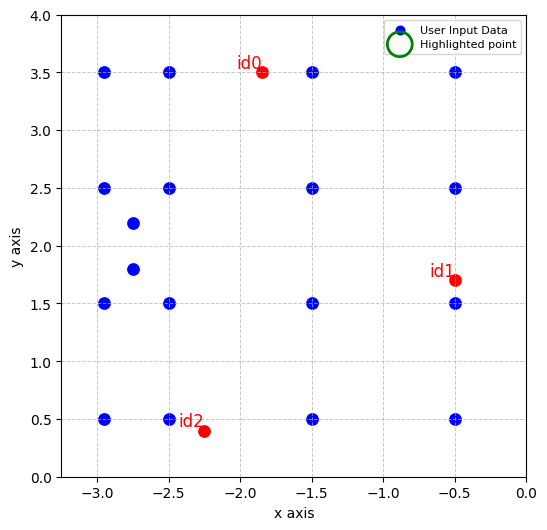

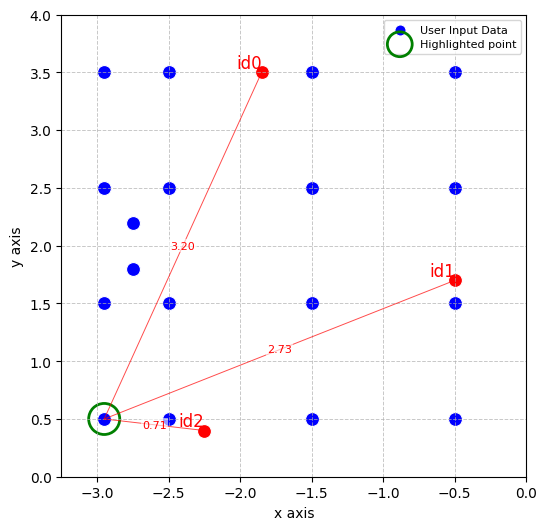

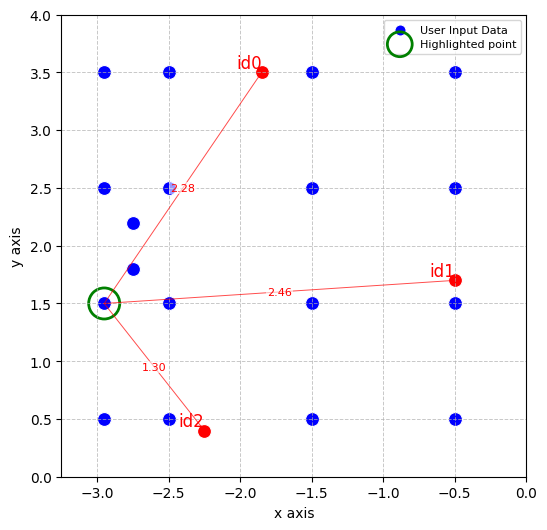

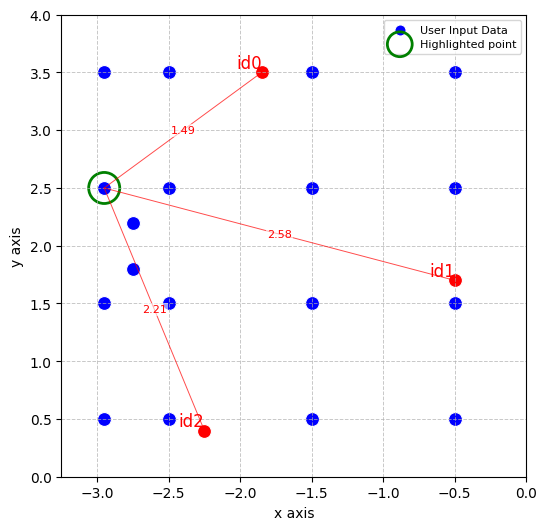

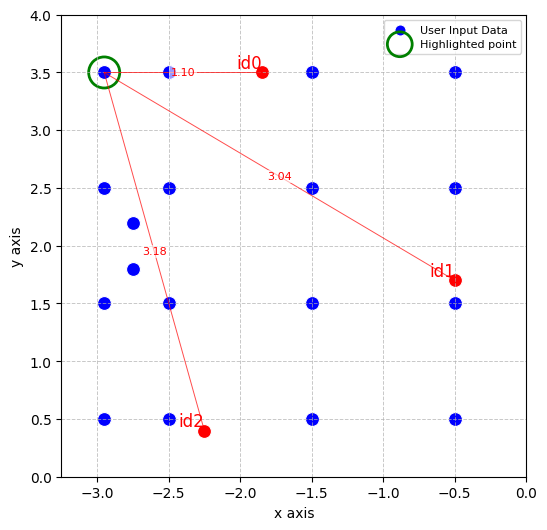

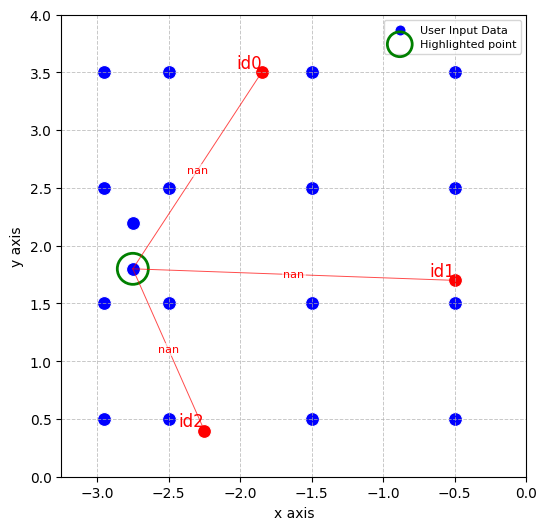

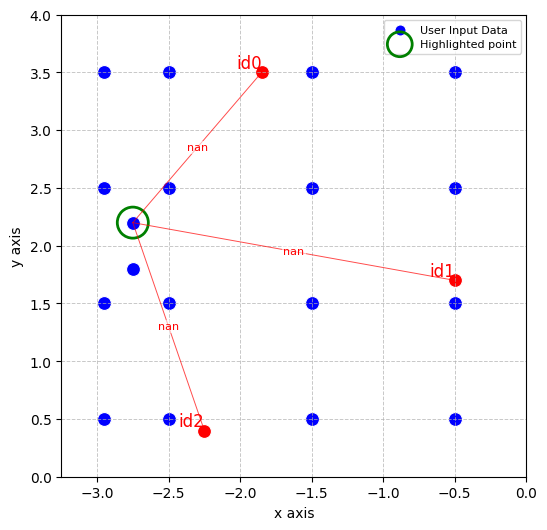

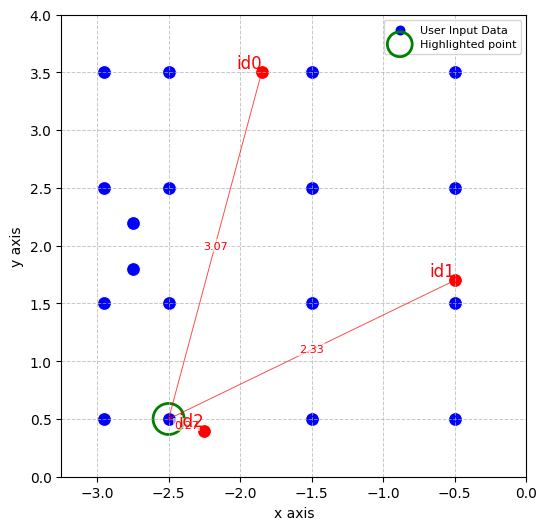

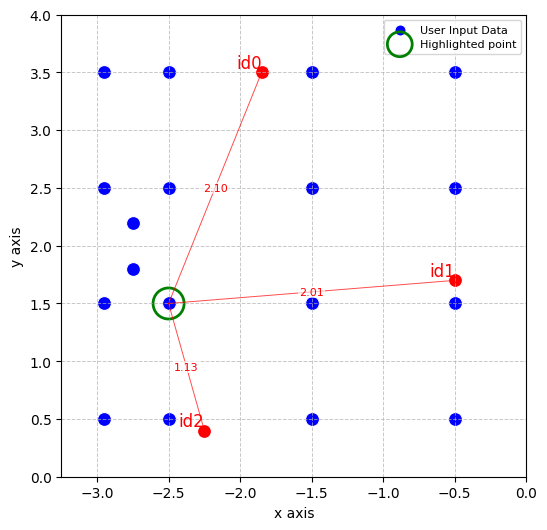

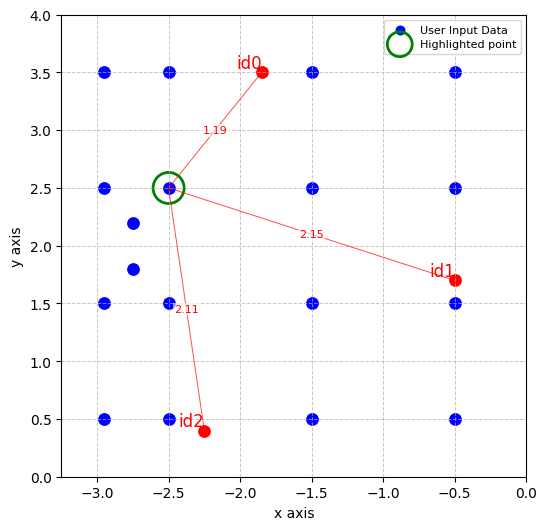

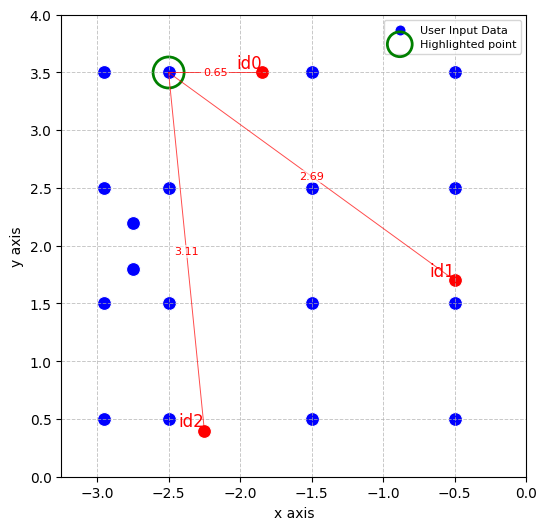

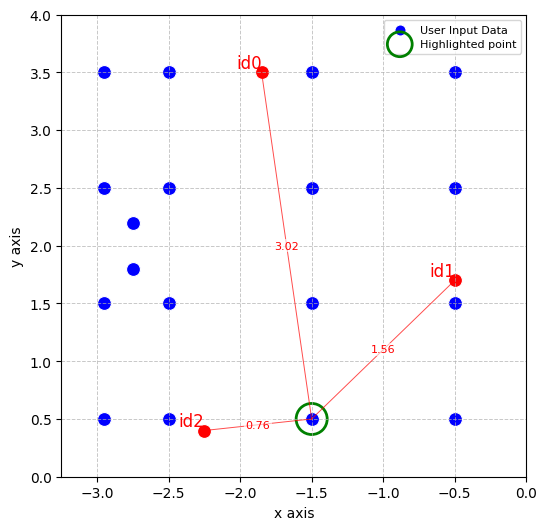

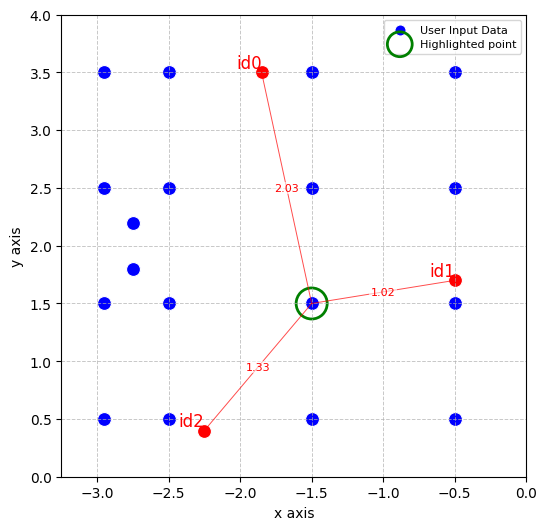

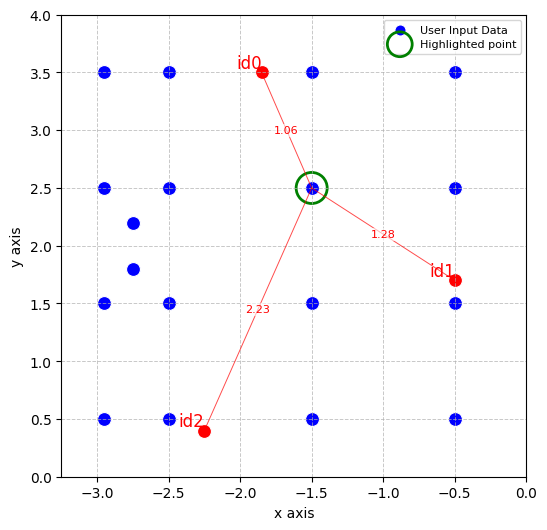

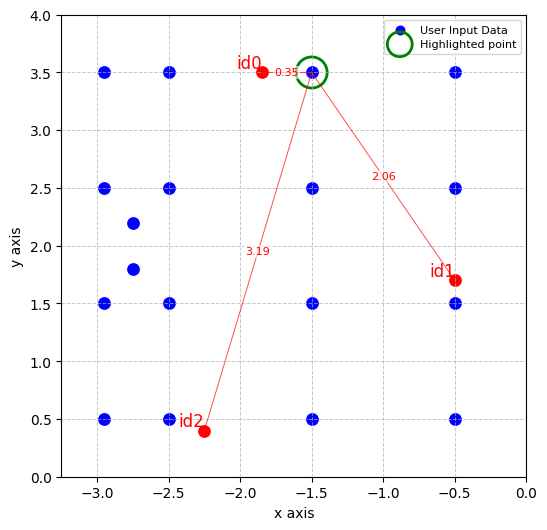

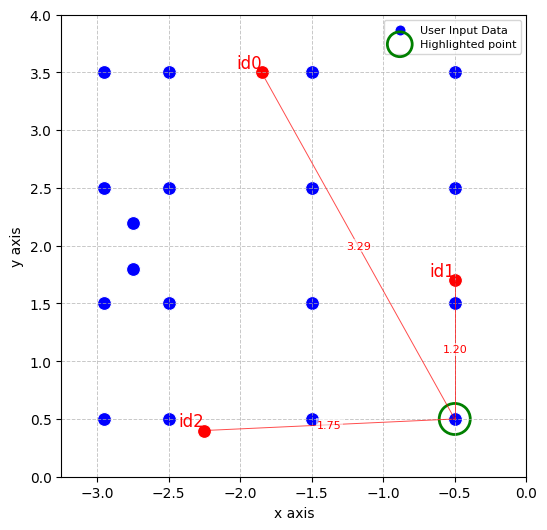

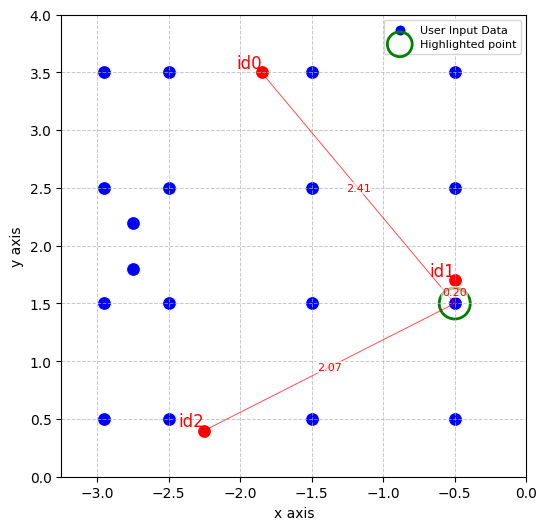

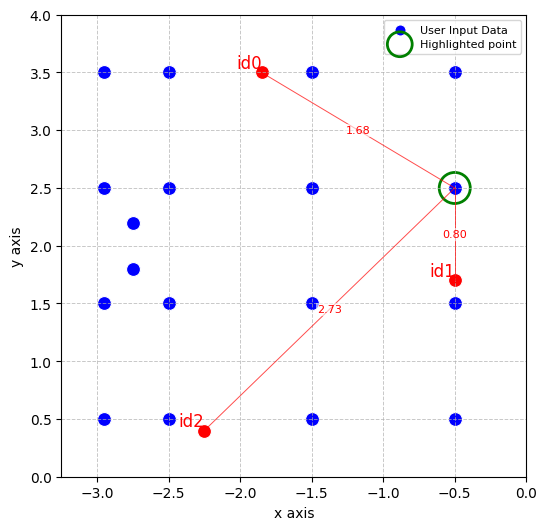

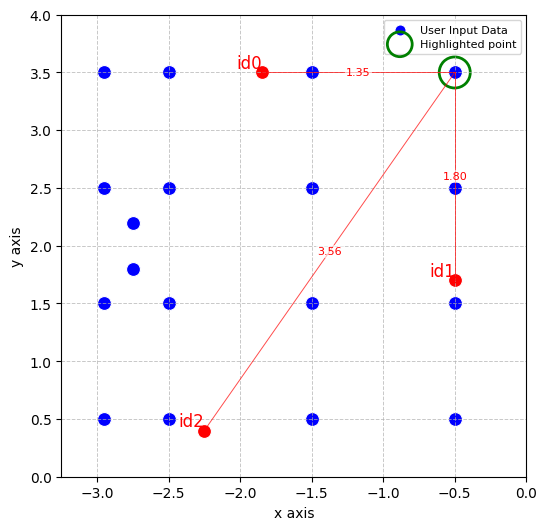

In [15]:
def plot_all_positions(userInputData):
    room_other_grouping = userInputData.groupby(["x axis","y axis"]).groups
    
    for group_name,indexes_of_the_group in room_other_grouping.items(): 
        sample_row_of_the_group = userInputData.loc[indexes_of_the_group[0],:]
        plot_position(userInputData,sample_row_of_the_group)        

plot_all_positions(userInputData)

sensors = timeSeriesData_BIG["sensors"].unique()
euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
group_by_list = ["room","experimentState",*euclidian_distances_columns]
room_other_grouping = userInputData.groupby(group_by_list).groups
type_of_other_grouping = ["experimentState","position","distance"]

sensors = timeSeriesData_BIG["sensors"].unique()
for sensor in sensors:
    mask = timeSeriesData_BIG["sensors"] == sensor
    timeSeriesData_BIG_subset = timeSeriesData_BIG.loc[mask,:]
    print(sensor)
    printDataBasedOnDate("VOC rolling average",userInputData,timeSeriesData_BIG_subset,room_other_grouping,type_of_other_grouping)

In [16]:
room_mask = userInputData["room"] == 'Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0'
experiment_state_mask = userInputData["experimentState"] == "InsertingSourcePollutant"
userInputDataModel = userInputData.loc[room_mask & experiment_state_mask].copy()
df_filtered = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputDataModel.index)]
dfs_by_sensor = {
    sensor: g
    for sensor, g in df_filtered.groupby("sensors")
}


In [17]:
dfs_by_sensor

{'Id=0:BME680:breathVocEquivalent':          keys                          sensors    VOC  after_insertion  \
 seconds                                                                  
 -30       146  Id=0:BME680:breathVocEquivalent  0.071            False   
 -29       146  Id=0:BME680:breathVocEquivalent  0.073            False   
 -28       146  Id=0:BME680:breathVocEquivalent  0.074            False   
 -27       146  Id=0:BME680:breathVocEquivalent  0.076            False   
 -26       146  Id=0:BME680:breathVocEquivalent  0.078            False   
 ...       ...                              ...    ...              ...   
  295      258  Id=0:BME680:breathVocEquivalent  2.093             True   
  296      258  Id=0:BME680:breathVocEquivalent  2.108             True   
  297      258  Id=0:BME680:breathVocEquivalent  2.114             True   
  298      258  Id=0:BME680:breathVocEquivalent  2.123             True   
  299      258  Id=0:BME680:breathVocEquivalent  2.143           

In [18]:
dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].columns

Index(['keys', 'sensors', 'VOC', 'after_insertion', 'original_value',
       'datetime_timestamp', 'timestamp', 'seconds',
       'seconds passed from insertionSource', 'VOC original',
       'VOC rolling average', 'original seconds', 'VOC-capped',
       'VOC rolling average-capped', 'VOC gradient',
       'VOC rolling average gradient',
       'VOC rolling average standard scaler whole experiment',
       'VOC rolling average-capped standard scaler whole experiment'],
      dtype='object')

In [19]:
userInputDataModel

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
146,InsertingSourcePollutant,None,None,None,1.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,None,2025-10-13 18:26:12,2025-10-13 18:24:06,2025-10-13 18:57:52,2025-10-13 00:00:00,2025-10-13 18:24:08,2025-10-13 18:57:50,0 days 00:33:42,0 days 00:02:05,125,0 days 00:31:37,0 days 00:02:05,125,1897,2022,270,-30,299,0.3738,251.0,0.3577,294,0.2026,224.0,Id=1:BME680:breathVocEquivalent MAX value VOC ...,Id=2:BME680:breathVocEquivalent MAX value VOC ...,0.34415,0.373413,0.33478,0.357013,0.18951,0.202442,0.32881,0.370132,0.059467,0.001485,0.068867,0.001000,0.087333,0.000453,-2.95,2.5,-1.85,3.5,-0.5,1.7,-2.25,0.4,1.49,2.58,2.21
147,InsertingSourcePollutant,None,None,None,0.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,0.3,None,None,2025-10-13 19:13:50,2025-10-13 19:11:41,2025-10-13 19:20:00,2025-10-13 00:00:00,2025-10-13 19:11:42,2025-10-13 19:19:59,0 days 00:08:17,0 days 00:02:09,129,0 days 00:06:08,0 days 00:02:09,129,368,497,270,-30,299,0.6778,229.0,0.9853,227,0.6536,299.0,Id=2:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.63975,0.676668,0.95069,0.984642,0.42454,0.643353,0.83994,0.982088,0.170633,0.000088,0.139667,0.001255,0.083233,0.001857,-2.95,3.5,-1.85,3.5,-0.5,1.7,-2.25,0.4,1.10,3.04,3.18
148,InsertingSourcePollutant,None,None,None,0.5,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",0.5,NaN,NaN,

In [20]:
sensors = timeSeriesData_BIG["sensors"].unique()

euclidian_distances_columns = [f"Euclidian distance to {sensor}" for sensor in sensors ]
userInputDataModel.loc[:,euclidian_distances_columns] = userInputDataModel.loc[:,euclidian_distances_columns].round(2)

In [21]:
userInputDataModel[euclidian_distances_columns].describe().loc[["min","max"]]

,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
min,0.35,0.20,0.27
max,3.29,3.04,3.56


In [22]:
for column in euclidian_distances_columns:
    print(userInputDataModel[column].unique())

[1.49 1.1  1.35 1.68 2.41 3.29 3.02 2.03 1.06 0.35 0.65 1.19 2.1  3.07
 3.2  2.28]
[2.58 3.04 1.8  0.8  0.2  1.2  1.56 1.02 1.28 2.06 2.69 2.15 2.01 2.33
 2.73 2.46]
[2.21 3.18 3.56 2.73 2.07 1.75 0.76 1.33 2.23 3.19 3.11 2.11 1.13 0.27
 0.71 1.3 ]


In [23]:
columns_to_keep = ["VOC rolling average"]

key_to_grab_size = userInputDataModel.index[0]
mask = dfs_by_sensor['Id=0:BME680:breathVocEquivalent']["keys"] == key_to_grab_size

sample_data = dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].loc[mask,columns_to_keep]
print(sample_data.shape[0])


330


In [24]:


columns_to_keep = ["VOC rolling average"]

key_to_grab_size = userInputDataModel.index[0]
mask = dfs_by_sensor['Id=0:BME680:breathVocEquivalent']["keys"] == key_to_grab_size

sample_data = dfs_by_sensor['Id=0:BME680:breathVocEquivalent'].loc[mask,columns_to_keep]

X_subset_columns_size = sample_data.shape[0]


sensors = timeSeriesData_BIG["sensors"].unique()
X ={}
Y ={}


dict_flattened_arrays_per_sensor_per_distance ={}
for sensor in sensors:
    X[sensor] = np.empty((0, X_subset_columns_size))
    Y[sensor] = np.empty((0, 1))
    dict_flattened_arrays_per_sensor_per_distance[sensor] = {}
    euclidian_distance_column = f"Euclidian distance to {sensor}"    
    
    for distance,experiments in userInputDataModel.groupby(euclidian_distance_column):

        rows_size = experiments.shape[0]
        X_distance_subset = np.empty((rows_size,X_subset_columns_size))

        for array_index,experiment_index in enumerate(experiments.index):
          
            mask = dfs_by_sensor[sensor]["keys"]== experiment_index
            flatten_array = dfs_by_sensor[sensor].loc[mask,columns_to_keep].to_numpy().reshape(1, -1)
            
            X_distance_subset[array_index,:] =   flatten_array
        X[sensor] = np.vstack((X[sensor],X_distance_subset))   
            

        Y_distance_subset = np.full((rows_size,1),distance)
        
        Y[sensor] = np.vstack((Y[sensor],Y_distance_subset))   


In [25]:
X

{'Id=0:BME680:breathVocEquivalent': array([[2.709000e-01, 2.778000e-01, 2.842000e-01, ..., 2.326000e+00,
         2.347700e+00, 2.372800e+00],
        [3.437000e-01, 3.437000e-01, 3.435000e-01, ..., 9.982626e+02,
         9.982626e+02, 9.982626e+02],
        [1.340100e+00, 1.355500e+00, 1.371900e+00, ..., 9.972198e+02,
         9.972198e+02, 9.972198e+02],
        ...,
        [2.870000e-02, 2.840000e-02, 2.810000e-02, ..., 5.250000e-02,
         5.330000e-02, 5.400000e-02],
        [2.588000e-01, 2.622000e-01, 2.653000e-01, ..., 7.476000e-01,
         7.431000e-01, 7.376000e-01],
        [4.690000e-01, 4.678000e-01, 4.665000e-01, ..., 2.132100e+00,
         2.135100e+00, 2.137800e+00]]),
 'Id=1:BME680:breathVocEquivalent': array([[4.290000e-02, 4.100000e-02, 3.930000e-02, ..., 2.340010e+01,
         2.325890e+01, 2.313200e+01],
        [2.821800e+00, 2.822400e+00, 2.822600e+00, ..., 3.293430e+01,
         3.215270e+01, 3.142330e+01],
        [2.605000e-01, 2.604000e-01, 2.598000e-01, 

In [26]:
Y

{'Id=0:BME680:breathVocEquivalent': array([[0.35],
        [0.35],
        [0.35],
        [0.35],
        [0.35],
        [0.35],
        [0.65],
        [0.65],
        [0.65],
        [0.65],
        [0.65],
        [0.65],
        [1.06],
        [1.06],
        [1.06],
        [1.06],
        [1.06],
        [1.06],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.1 ],
        [1.19],
        [1.19],
        [1.19],
        [1.19],
        [1.19],
        [1.19],
        [1.35],
        [1.35],
        [1.35],
        [1.35],
        [1.35],
        [1.35],
        [1.49],
        [1.49],
        [1.49],
        [1.49],
        [1.49],
        [1.49],
        [1.49],
        [1.68],
        [1.68],
        [1.68],
        [1.68],
        [1.68],
        [1.68],
        [2.03],
        [2.03],
        [2.03],
        [2.03],
        [2.03],
        [2.03],
        [2.1 ],
        [2.1 ],
        [2.1 ],
        [2.1 ],
     

In [27]:
X.keys()

dict_keys(['Id=0:BME680:breathVocEquivalent', 'Id=1:BME680:breathVocEquivalent', 'Id=2:BME680:breathVocEquivalent'])

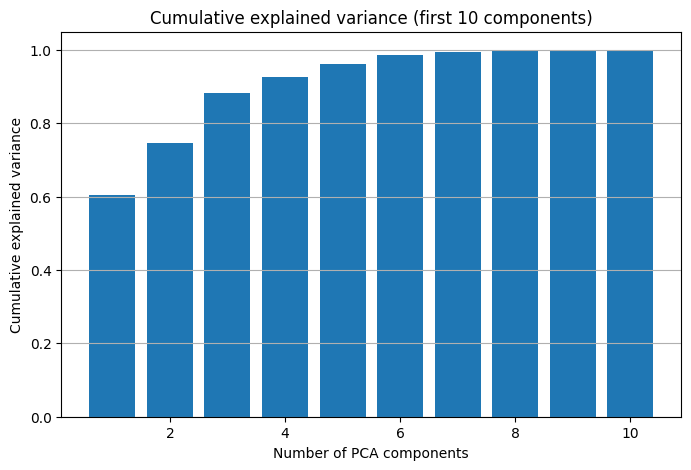

Optimal number of components to explain ~90% variance: 4


In [28]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X['Id=0:BME680:breathVocEquivalent'])

# Step 2: Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Step 3: Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Only display first 10 components max
max_components = min(10, len(explained_variance))
ev_to_plot = explained_variance[:max_components]
cum_to_plot = cumulative_variance[:max_components]

# Step 4: Bar plot of cumulative explained variance
plt.figure(figsize=(8,5))
plt.bar(range(1, max_components + 1), cum_to_plot)
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('Cumulative explained variance (first 10 components)')
plt.grid(True, axis='y')
plt.show()

# Step 5: Optimal number of components for ~90% variance
optimal_components = np.argmax(cumulative_variance >= 0.90) + 1
print("Optimal number of components to explain ~90% variance:", optimal_components)


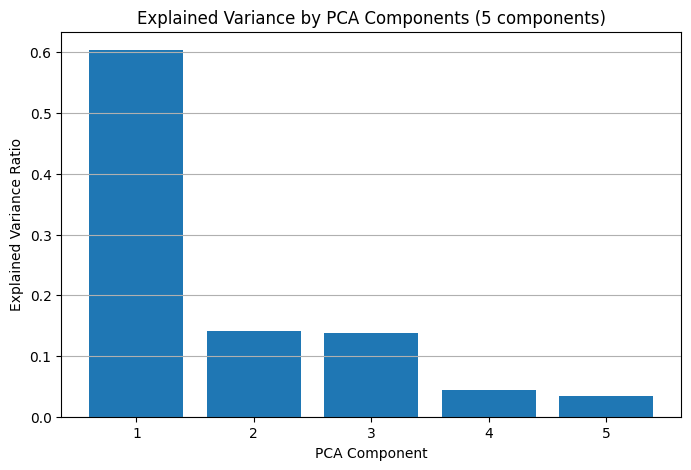

In [29]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X['Id=0:BME680:breathVocEquivalent'])

# Step 2: Apply PCA with 5 components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Explained variance for each of the 5 components
explained_variance = pca.explained_variance_ratio_

# Step 3: Bar plot of explained variance (per component)
plt.figure(figsize=(8,5))
plt.bar(range(1, 6), explained_variance)
plt.xlabel('PCA Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by PCA Components (5 components)')
plt.grid(True, axis='y')
plt.show()

'Id=0:BME680:breathVocEquivalent'

MSE on test set: 0.7254
R^2 on test set: 0.1747


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


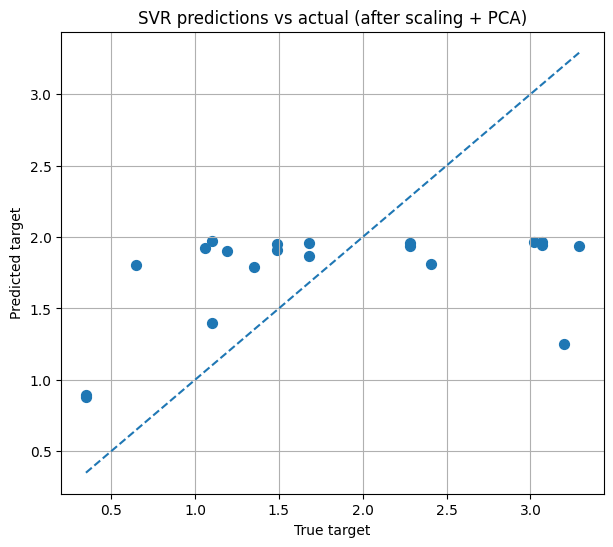

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# --- Config ---
n_components = 5         # number of PCA components you chose
test_size = 0.2           # fraction for test set
random_state = 42         # predefined random state for reproducibility

# --- Get arrays (ensure they're numpy arrays) ---
X_arr = np.asarray(X['Id=0:BME680:breathVocEquivalent'])
y_arr = np.asarray(Y['Id=0:BME680:breathVocEquivalent'])


# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=test_size, random_state=random_state, shuffle=True
)

# --- Scale: fit on train, transform train & test ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train
X_test_scaled  = scaler.transform(X_test)        # transform only

# --- PCA: fit on scaled train, transform both ---
pca = PCA(n_components=n_components, random_state=random_state)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- SVR: train on PCA data ---
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)  # tune C, epsilon, kernel as needed
svr.fit(X_train_pca, y_train)

# --- Predict & evaluate ---
y_pred = svr.predict(X_test_pca)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE on test set: {mse:.4f}")
print(f"R^2 on test set: {r2:.4f}")

# --- Plot: predicted vs actual ---
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("True target")
plt.ylabel("Predicted target")
plt.title("SVR predictions vs actual (after scaling + PCA)")
plt.grid(True)
plt.show()


In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.001, 0.01, 0.1, 0.2],
    "gamma": ["scale", "auto"]
}

svr = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=svr_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

svr.fit(X_train_pca, y_train)
print("SVR best params:", svr.best_params_)

from sklearn.metrics import mean_squared_error, r2_score

best_model = svr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________



from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf.fit(X_train_pca, y_train)
print("Random Forest best params:", rf.best_params_)


best_model = rf.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.ensemble import GradientBoostingRegressor

gbr_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gbr_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

gbr.fit(X_train_pca, y_train)
print("GradientBoosting best params:", gbr.best_params_)

best_model = gbr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.neighbors import KNeighborsRegressor

knn_params = {
    "n_neighbors": [2, 3, 4, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]   # Manhattan / Euclidean
}

knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

knn.fit(X_train_pca, y_train)
print("KNN best params:", knn.best_params_)


best_model = knn.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Ridge

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

ridge.fit(X_train_pca, y_train)
print("Ridge best params:", ridge.best_params_)

best_model = ridge.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Lasso

lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

lasso.fit(X_train_pca, y_train)
print("Lasso best params:", lasso.best_params_)


best_model = lasso.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


Fitting 5 folds for each of 32 candidates, totalling 160 fits


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best params: {'C': 1, 'epsilon': 0.001, 'gamma': 'scale'}
Test MSE: 0.7333218703089834
Test R² : 0.16560327364479743
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest best params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Test MSE: 0.8736713022414004
Test R² : 0.005909268472309881
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoosting best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Test MSE: 0.6438233197441823
Test R² : 0.26743754400869735
Fitting 5 folds for each of 24 candidates, totalling 120 fits
KNN best params: {'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Test MSE: 0.7492804938271604
Test R² : 0.14744504905088018
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Ridge best params: {'alpha': 100}
Test MSE: 1.0244381396690914
Test R² : -0.16563798885902692
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Lasso best params: {'alpha': 1}
Test MSE: 0.7391820885465146
Test R² : 0.15893533271585347


'Id=1:BME680:breathVocEquivalent'

MSE on test set: 0.4107
R^2 on test set: 0.3992


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


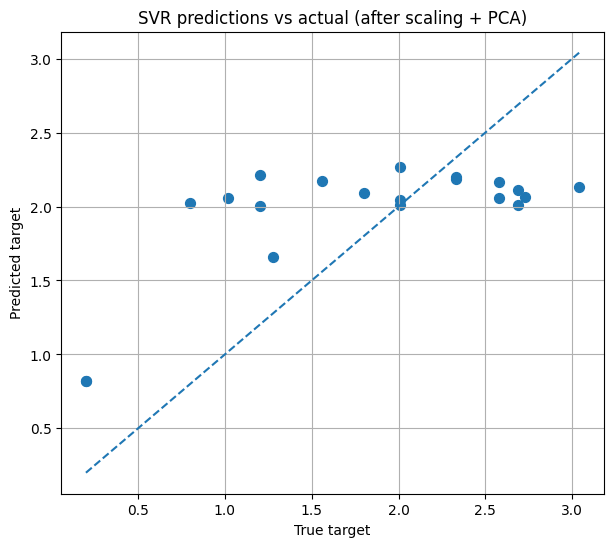

In [54]:
# --- Config ---
n_components = 5         # number of PCA components you chose
test_size = 0.2           # fraction for test set
random_state = 42         # predefined random state for reproducibility

# --- Get arrays (ensure they're numpy arrays) ---
X_arr = np.asarray(X['Id=1:BME680:breathVocEquivalent'])
y_arr = np.asarray(Y['Id=1:BME680:breathVocEquivalent'])


# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=test_size, random_state=random_state, shuffle=True
)

# --- Scale: fit on train, transform train & test ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train
X_test_scaled  = scaler.transform(X_test)        # transform only

# --- PCA: fit on scaled train, transform both ---
pca = PCA(n_components=n_components, random_state=random_state)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- SVR: train on PCA data ---
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)  # tune C, epsilon, kernel as needed
svr.fit(X_train_pca, y_train)

# --- Predict & evaluate ---
y_pred = svr.predict(X_test_pca)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE on test set: {mse:.4f}")
print(f"R^2 on test set: {r2:.4f}")

# --- Plot: predicted vs actual ---
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("True target")
plt.ylabel("Predicted target")
plt.title("SVR predictions vs actual (after scaling + PCA)")
plt.grid(True)
plt.show()


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.001, 0.01, 0.1, 0.2],
    "gamma": ["scale", "auto"]
}

svr = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=svr_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

svr.fit(X_train_pca, y_train)
print("SVR best params:", svr.best_params_)

from sklearn.metrics import mean_squared_error, r2_score

best_model = svr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________



from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf.fit(X_train_pca, y_train)
print("Random Forest best params:", rf.best_params_)


best_model = rf.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.ensemble import GradientBoostingRegressor

gbr_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gbr_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

gbr.fit(X_train_pca, y_train)
print("GradientBoosting best params:", gbr.best_params_)

best_model = gbr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.neighbors import KNeighborsRegressor

knn_params = {
    "n_neighbors": [2, 3, 4, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]   # Manhattan / Euclidean
}

knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

knn.fit(X_train_pca, y_train)
print("KNN best params:", knn.best_params_)


best_model = knn.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Ridge

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

ridge.fit(X_train_pca, y_train)
print("Ridge best params:", ridge.best_params_)

best_model = ridge.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Lasso

lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

lasso.fit(X_train_pca, y_train)
print("Lasso best params:", lasso.best_params_)


best_model = lasso.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


Fitting 5 folds for each of 32 candidates, totalling 160 fits


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best params: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
Test MSE: 0.3576776775264796
Test R² : 0.4767206205329684
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Test MSE: 0.47294088588307953
Test R² : 0.308091533693308
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoosting best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}
Test MSE: 0.5286806820761866
Test R² : 0.2265446891564734
Fitting 5 folds for each of 24 candidates, totalling 120 fits
KNN best params: {'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}
Test MSE: 0.5984490740740741
Test R² : 0.12447412908255218
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Ridge best params: {'alpha': 100}
Test MSE: 2.1486123551063505
Test R² : -2.1434014771917442
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Lasso best params: {'alpha': 0.1}
Test MSE: 1.7660942382084106
Test R² : -1.5837807476301884


'Id=2:BME680:breathVocEquivalent'

MSE on test set: 0.6706
R^2 on test set: 0.3562


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


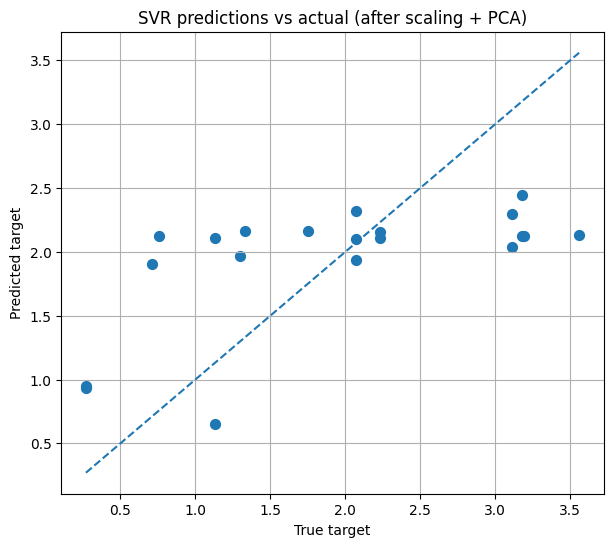

In [56]:
# --- Config ---
n_components = 5         # number of PCA components you chose
test_size = 0.2           # fraction for test set
random_state = 42         # predefined random state for reproducibility

# --- Get arrays (ensure they're numpy arrays) ---
X_arr = np.asarray(X['Id=2:BME680:breathVocEquivalent'])
y_arr = np.asarray(Y['Id=2:BME680:breathVocEquivalent'])


# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=test_size, random_state=random_state, shuffle=True
)

# --- Scale: fit on train, transform train & test ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train
X_test_scaled  = scaler.transform(X_test)        # transform only

# --- PCA: fit on scaled train, transform both ---
pca = PCA(n_components=n_components, random_state=random_state)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# --- SVR: train on PCA data ---
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)  # tune C, epsilon, kernel as needed
svr.fit(X_train_pca, y_train)

# --- Predict & evaluate ---
y_pred = svr.predict(X_test_pca)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE on test set: {mse:.4f}")
print(f"R^2 on test set: {r2:.4f}")

# --- Plot: predicted vs actual ---
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("True target")
plt.ylabel("Predicted target")
plt.title("SVR predictions vs actual (after scaling + PCA)")
plt.grid(True)
plt.show()


In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr_params = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.001, 0.01, 0.1, 0.2],
    "gamma": ["scale", "auto"]
}

svr = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=svr_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

svr.fit(X_train_pca, y_train)
print("SVR best params:", svr.best_params_)

from sklearn.metrics import mean_squared_error, r2_score

best_model = svr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________



from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf.fit(X_train_pca, y_train)
print("Random Forest best params:", rf.best_params_)


best_model = rf.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.ensemble import GradientBoostingRegressor

gbr_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gbr_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

gbr.fit(X_train_pca, y_train)
print("GradientBoosting best params:", gbr.best_params_)

best_model = gbr.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.neighbors import KNeighborsRegressor

knn_params = {
    "n_neighbors": [2, 3, 4, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]   # Manhattan / Euclidean
}

knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

knn.fit(X_train_pca, y_train)
print("KNN best params:", knn.best_params_)


best_model = knn.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Ridge

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

ridge.fit(X_train_pca, y_train)
print("Ridge best params:", ridge.best_params_)

best_model = ridge.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))

#____________________________________________________
#____________________________________________________
#____________________________________________________

from sklearn.linear_model import Lasso

lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

lasso.fit(X_train_pca, y_train)
print("Lasso best params:", lasso.best_params_)


best_model = lasso.best_estimator_   # replace with svr, gbr, knn, ridge, lasso…

y_pred = best_model.predict(X_test_pca)

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R² :", r2_score(y_test, y_pred))


Fitting 5 folds for each of 32 candidates, totalling 160 fits


C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR best params: {'C': 1, 'epsilon': 0.1, 'gamma': 'scale'}
Test MSE: 0.6705653595854997
Test R² : 0.35617819348007973
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
Test MSE: 0.7448725148004451
Test R² : 0.2848345634759676
Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoosting best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}
Test MSE: 0.8789423665251901
Test R² : 0.15611169865241215
Fitting 5 folds for each of 24 candidates, totalling 120 fits
KNN best params: {'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}
Test MSE: 0.8709656122448978
Test R² : 0.16377032324059215
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Ridge best params: {'alpha': 100}
Test MSE: 1.1431895119102382
Test R² : -0.09759671631059152
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Lasso best params: {'alpha': 1}
Test MSE: 0.7618075581570075
Test R² : 0.26857492517008374
